<span style="color: blue;">**Predicting the Employee Performance**</span>

**Project Overview**

This project develops a machine learning model to predict employee performance levels based on demographic, job-related, and organizational factors such as age, education, department, job role, satisfaction levels, overtime, and work experience. The aim is to identify key drivers of performance and support data-driven HR decision-making.


Multiple classification models, including XGBoost, Random Forest, KNN, Decision Tree, Logistic Regression, and SVM, were evaluated using Stratified Cross-Validation with Accuracy. The best-performing model was XGBoost, which achieved the highest predictive performance.


Further analysis was carried out using RFE feature selection to determine the most influential factors affecting employee performance. The top 10 features were selected, and the final model was trained and evaluated using these features.


**Live Application (Streamlit)**


[Employee Performance Prediction](https://employee-performance-prediction90.streamlit.app/)

The deployed web application allows users to input employee demographic, job-related, and organizational details and receive real-time predictions of employee performance levels, helping HR teams make data-driven decisions on workforce performance and management.

In [93]:
# Data Handling & Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Feature Engineering
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE

# Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#  Machine Learning Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

#  Model Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [94]:
# Import the dataset from an Excel file into a pandas DataFrame
df = pd.read_excel(
    "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"
)

# Set pandas display option to show all columns when printing the DataFrame
pd.set_option("display.max_columns", None)

# Display the first 5 rows of the dataset to get a quick overview of the data structure
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [95]:
# Display the total number of rows in the dataset (number of employee records)
print('Number of Rows', df.shape[0])

# Display the total number of columns in the dataset (number of features/variables)
print('Number of Columns', df.shape[1])

Number of Rows 1200
Number of Columns 28


In [96]:
# Show dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [97]:
# Check total number of missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

In [98]:
# Summary statistics of numerical features (transposed)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1200.0,36.918333,9.087289,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1200.0,9.165833,8.176636,1.0,2.0,7.0,14.0,29.0
EmpEducationLevel,1200.0,2.892500,1.044120,1.0,2.0,3.0,4.0,5.0
EmpEnvironmentSatisfaction,1200.0,2.715833,1.090599,1.0,2.0,3.0,4.0,4.0
EmpHourlyRate,1200.0,65.981667,20.211302,30.0,48.0,66.0,83.0,100.0
EmpJobInvolvement,1200.0,2.731667,0.707164,1.0,2.0,3.0,3.0,4.0
EmpJobLevel,1200.0,2.067500,1.107836,1.0,1.0,2.0,3.0,5.0
EmpJobSatisfaction,1200.0,2.732500,1.100888,1.0,2.0,3.0,4.0,4.0
NumCompaniesWorked,1200.0,2.665000,2.469384,0.0,1.0,2.0,4.0,9.0
EmpLastSalaryHikePercent,1200.0,15.222500,3.625918,11.0,12.0,14.0,18.0,25.0


<span style="color: blue;">**EXPLORATORY DATA ANALYSIS**</span>

<span style="color: blue;">**UNIVARIATE ANALYSIS**</span>

In [99]:
# Map numerical performance ratings to descriptive labels
rating_map = {
    1: "Low",
    2: "Good",
    3: "Excellent",
    4: "Outstanding"
}

df["PerformanceRatingLabel"] = df["PerformanceRating"].map(rating_map)

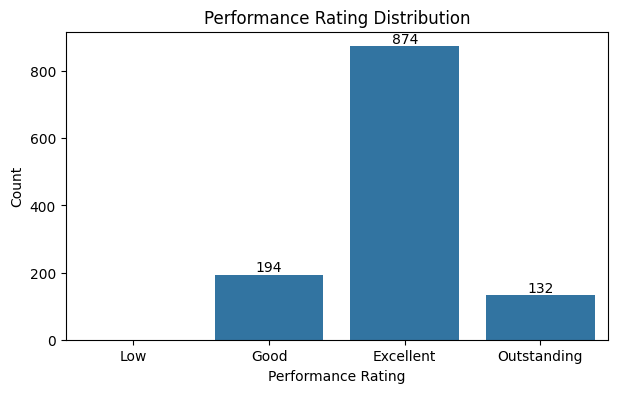

In [100]:
# Set figure size for the plot
plt.figure(figsize=(7,4))

# Plot distribution of performance ratings
ax = sns.countplot(
    x="PerformanceRatingLabel",
    data=df,
    order=["Low", "Good", "Excellent", "Outstanding"]
)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

# Add chart title and axis labels
plt.title("Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Count")

plt.show()

The chart shows the distribution of employee performance at INX Future Inc. Most employees (874) are rated Excellent, followed by Good (194) and Outstanding (132), with no employees in the Low category.

This indicates that the workforce is generally high-performing, but the distribution is heavily concentrated in the "Excellent" group.

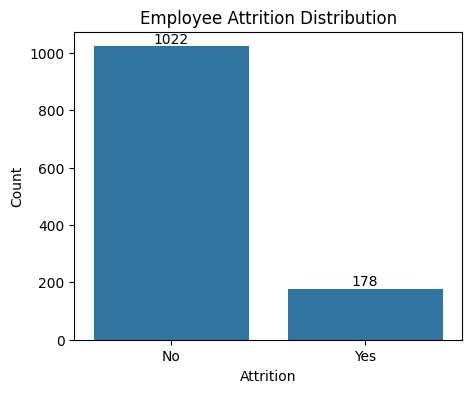

In [101]:
# Set figure size
plt.figure(figsize=(5,4))

# Plot attrition distribution
ax = sns.countplot(x="Attrition", data=df)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

# Add titles and labels
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

The chart shows the employee attrition distribution at INX Future Inc. Most employees (1,022, about 85%) have stayed with the company, while 178 employees (about 15%) have left.

Although retention is generally high, there is still a noticeable attrition rate.

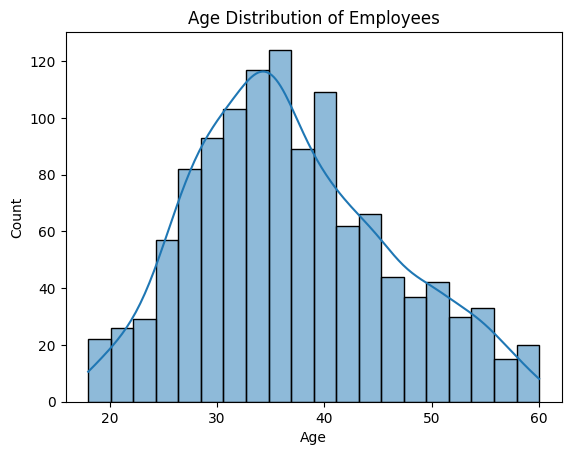

In [102]:
# Plot age distribution with histogram and density curve
plt.figure()
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Employees")
plt.show()

The histogram shows the age distribution of employees at INX Future Inc., ranging from 18 to 60 years. Most employees fall within the 30-40 age group, with an average age of around 36-37, indicating a predominantly mid-career workforce.

The distribution is slightly right-skewed, meaning there are fewer older employees as age increases.

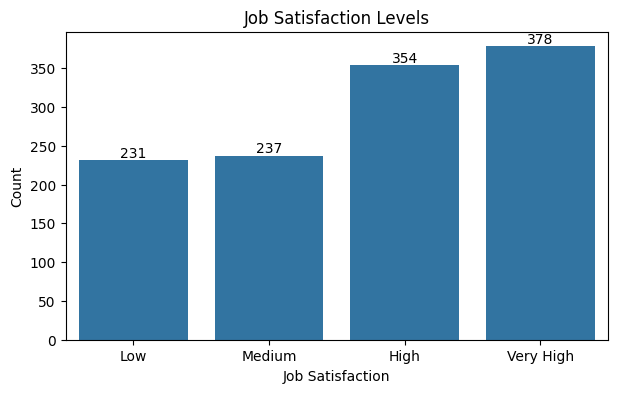

In [103]:
# Map job satisfaction scores to descriptive labels
df["EmpJobSatisfactionLabel"] = df["EmpJobSatisfaction"].map({
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
})

# Set figure size
plt.figure(figsize=(7,4))

# Define order of categories
order = ["Low", "Medium", "High", "Very High"]

# Plot job satisfaction distribution
ax = sns.countplot(
    x="EmpJobSatisfactionLabel",
    data=df,
    order=order
)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

# Add titles and axis labels
plt.title("Job Satisfaction Levels")
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")

plt.show()

The chart shows the job satisfaction levels of employees at INX Future Inc. Most employees report high (354) or very high (378) satisfaction, indicating a generally positive work environment. However, a notable number fall into medium (237) and low (231) satisfaction levels.

This suggests that while the majority are satisfied, a significant portion of employees may be disengaged, which could be contributing to performance issues and declining client satisfaction.

In [104]:
# Select your numerical columns
num_cols = [
    "DistanceFromHome",
    "EmpHourlyRate",
    "EmpLastSalaryHikePercent",
    "TotalWorkExperienceInYears",
    "TrainingTimesLastYear",
    "ExperienceYearsAtThisCompany",
    "ExperienceYearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "Age"
]

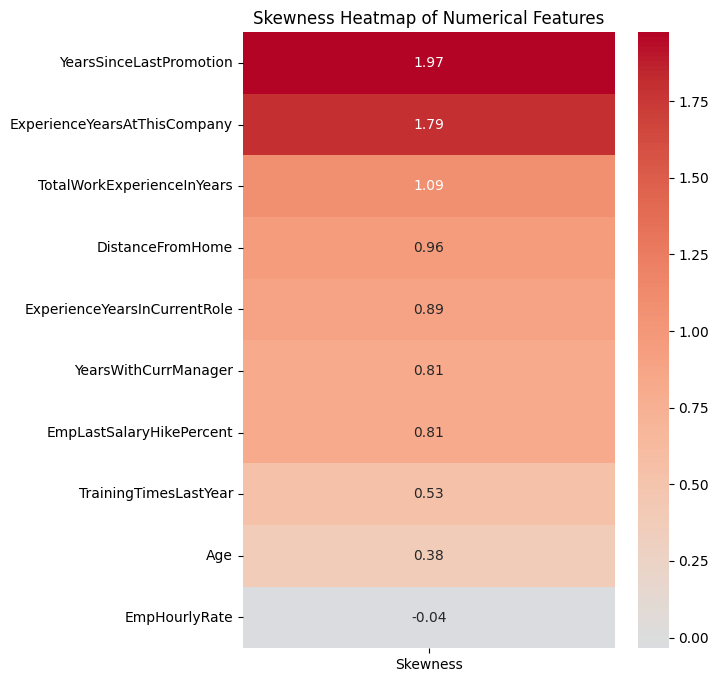

In [105]:
# Calculate skewness of numerical features and sort in descending order
skew_values = df[num_cols].skew().sort_values(ascending=False)

# Convert skewness values into a DataFrame for visualization
skew_df = skew_values.to_frame(name="Skewness")

# Plot skewness heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    skew_df,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

# Add title
plt.title("Skewness Heatmap of Numerical Features")

plt.show()

The skewness values show how **unevenly distributed** the numerical features are in the dataset. Some variables, like **Years Since Last Promotion**, **Experience at Company**, and **Total Work Experience**, are highly positively skewed, meaning most employees have lower values with a few extreme high cases (outliers).

Moderately skewed features, such as **Distance from Home** and **Salary Hike Percent**, show some imbalance but are less extreme. Meanwhile, variables like **Age** and **Hourly Rate** are fairly symmetric, indicating a balanced distribution.

Highly skewed features may need transformation (e.g., log scaling) to improve model performance and ensure more reliable predictions.


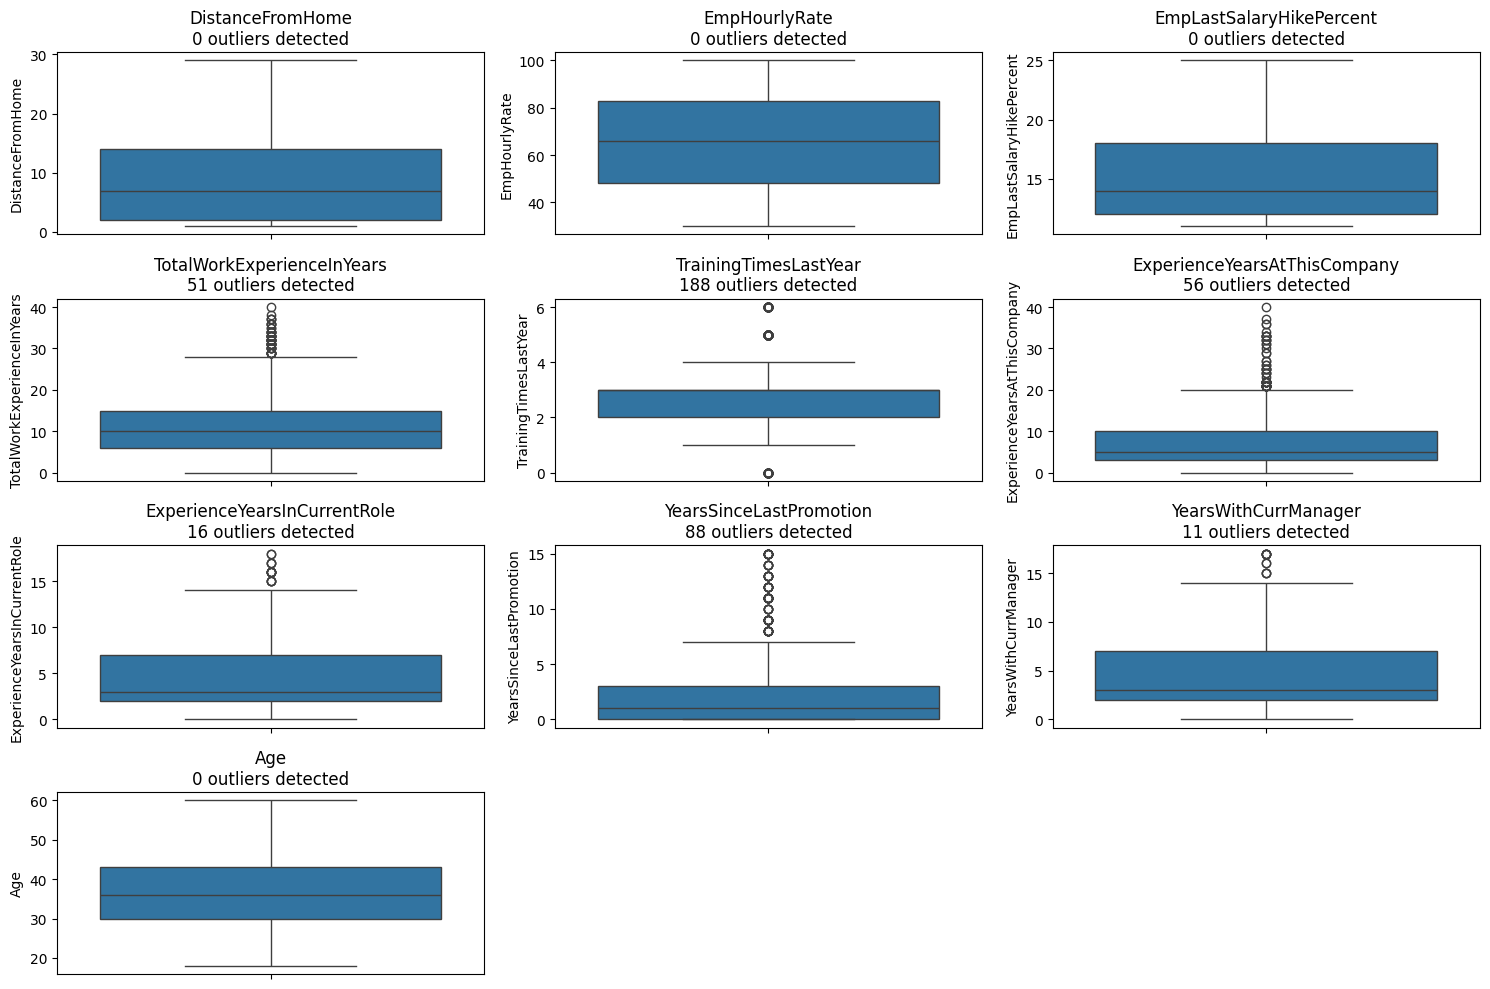

In [106]:
# Set overall figure size for multiple boxplots
plt.figure(figsize=(15,10))

# Loop through all numerical columns
for i, col in enumerate(num_cols):

    # Calculate Q1, Q3 and IQR for outlier detection
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds for outliers
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify outliers in the column
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_count = outliers.shape[0]

    # Create boxplot for each feature
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=df[col])

    # Show feature name and number of outliers
    plt.title(f"{col}\n{outlier_count} outliers detected")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The boxplots show the presence of outliers in several numerical variables within the dataset. Features like TrainingTimesLastYear, YearsSinceLastPromotion, and ExperienceYearsAtThisCompany have many extreme values, indicating that some employees differ significantly from the majority.

On the other hand, variables such as Age, DistanceFromHome, and Hourly Rate show little to no outliers, meaning they are more consistent across employees.

<span style="color: blue;">**BIVARIATE ANALYSIS**</span>

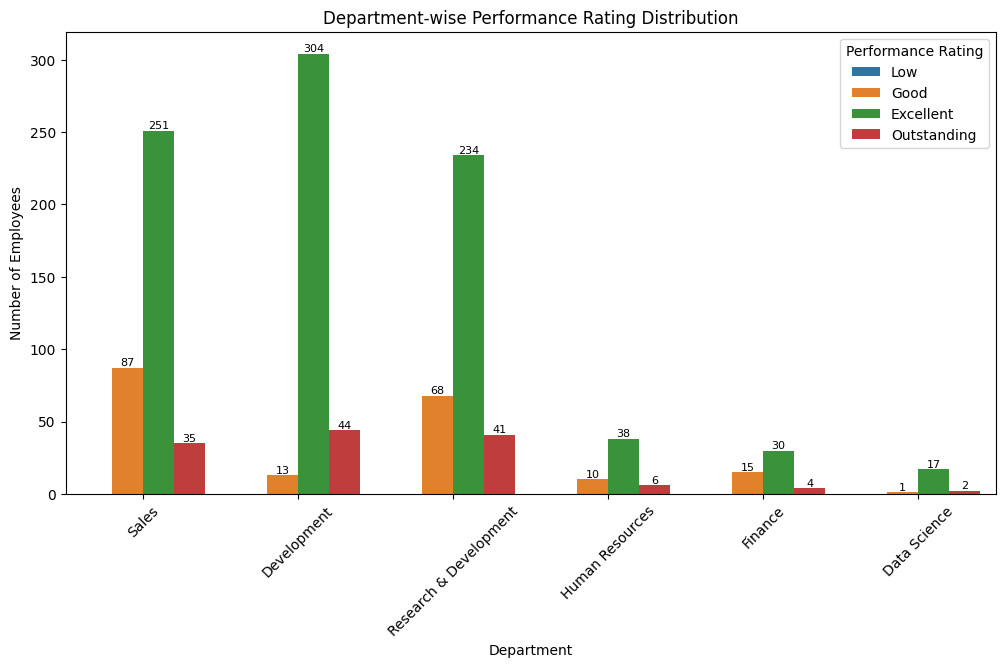

In [107]:
# Map performance ratings to descriptive labels
rating_map = {
    1: "Low",
    2: "Good",
    3: "Excellent",
    4: "Outstanding"
}

df["PerformanceRatingLabel"] = df["PerformanceRating"].map(rating_map)

# Set figure size
plt.figure(figsize=(12,6))

# Plot department-wise performance distribution
ax = sns.countplot(
    x="EmpDepartment",
    hue="PerformanceRatingLabel",
    data=df,
    order=df["EmpDepartment"].value_counts().index,
    hue_order=["Low", "Good", "Excellent", "Outstanding"]
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)

# Add titles and labels
plt.title("Department-wise Performance Rating Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(title="Performance Rating")

plt.show()

The chart shows department-wise performance ratings across the company. Most employees in all departments are rated Excellent, but there are noticeable differences between teams.

Departments like Development and Research & Development have strong and consistent high performance, while Sales has a larger number of employees in the "Good" category, indicating more variation in performance. Smaller teams like Data Science maintain high-quality performance despite their size.

The chart suggests that performance levels vary by department, and areas with more "Good" ratings may need improvement to boost overall productivity and service delivery.

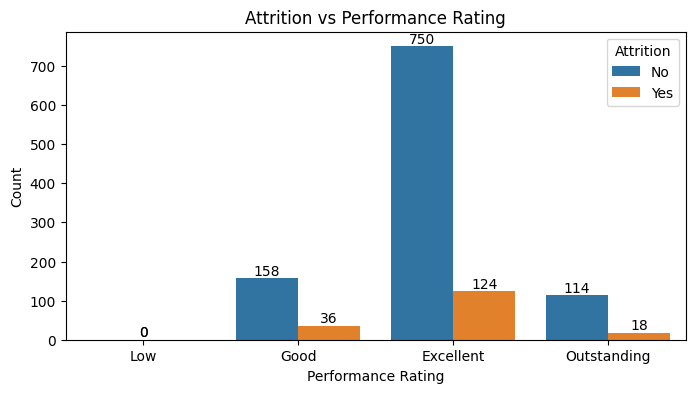

In [108]:
# Set figure size
plt.figure(figsize=(8,4))

# Plot attrition distribution across performance ratings
ax = sns.countplot(
    x="PerformanceRatingLabel",
    hue="Attrition",
    data=df,
    order=["Low", "Good", "Excellent", "Outstanding"]
)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

# Add titles and labels
plt.title("Attrition vs Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("Count")

plt.show()

The chart shows the relationship between attrition and performance rating. While most employees across all performance levels remain in the company, a notable number have left, especially from the Excellent category.

This means that even high-performing employees are leaving the organization, which is a key concern. The loss of top talent (Excellent and Outstanding) may be contributing to declining service delivery and client satisfaction, highlighting the need for stronger retention strategies focused on high performers.

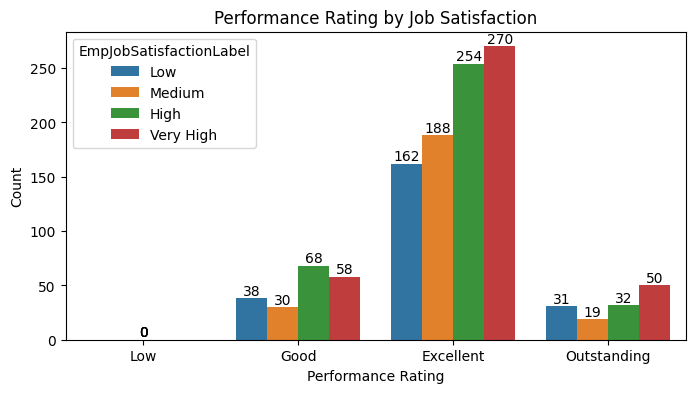

In [109]:
# Set figure size
plt.figure(figsize=(8,4))

# Plot performance rating against job satisfaction
ax = sns.countplot(
    x="PerformanceRatingLabel",
    hue="EmpJobSatisfactionLabel",
    data=df,
    order=["Low", "Good", "Excellent", "Outstanding"],
    hue_order=["Low", "Medium", "High", "Very High"]
)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

# Add titles and labels
plt.title("Performance Rating by Job Satisfaction")
plt.xlabel("Performance Rating")
plt.ylabel("Count")

plt.show()

The chart shows the relationship between job satisfaction and performance rating at INX Future Inc. It indicates a clear positive trend where employees with higher job satisfaction tend to achieve better performance ratings, especially in the Excellent and Outstanding categories.

Most top performers report high or very high satisfaction, while lower satisfaction levels are more mixed within the "Good" performance group. However, some high-performing employees still report low satisfaction, which may signal a risk of future attrition.

Overall, the chart suggests that job satisfaction is strongly linked to employee performance, making it an important factor for improving productivity and retention.

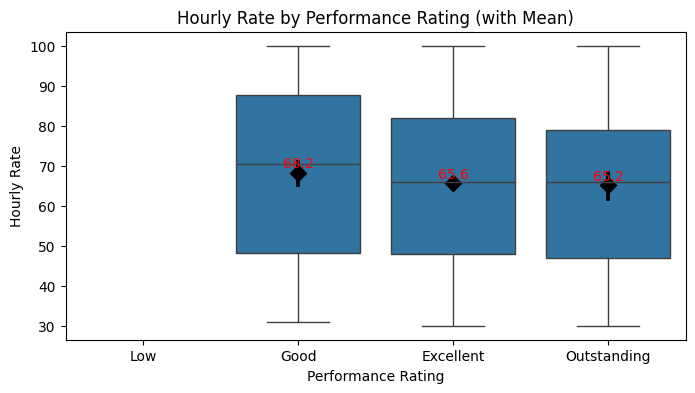

In [110]:
# Set figure size
plt.figure(figsize=(8,4))

# Define order of performance categories
order = ["Low", "Good", "Excellent", "Outstanding"]

# Create boxplot of hourly rate by performance rating
ax = sns.boxplot(
    x="PerformanceRatingLabel",
    y="EmpHourlyRate",
    data=df,
    order=order
)

# Compute mean hourly rate for each performance group
means = df.groupby("PerformanceRatingLabel")["EmpHourlyRate"].mean().reindex(order)

# Add mean values as text labels on the plot
for i, val in enumerate(means):
    ax.text(
        i,
        val + 0.5,
        f"{val:.1f}",
        ha='center',
        va='bottom',
        color='red'
    )

# Plot mean points for each category
sns.pointplot(
    x="PerformanceRatingLabel",
    y="EmpHourlyRate",
    data=df,
    order=order,
    estimator="mean",
    color="black",
    markers="D",
    linestyles=""
)

# Add titles and labels
plt.title("Hourly Rate by Performance Rating (with Mean)")
plt.xlabel("Performance Rating")
plt.ylabel("Hourly Rate")

plt.show()

The boxplot shows the relationship between hourly rate and performance rating at INX Future Inc. It reveals an unexpected pattern where lower-performing employees ("Good") have the highest average hourly rate (68.2), followed by "Excellent" (65.6), while "Outstanding" performers receive the lowest average rate (65.2).

This indicates a reverse or misaligned reward structure, where pay does not increase with performance. Such a gap may reduce motivation among top performers and could contribute to declining performance and service delivery issues, including the reported drop in client satisfaction.

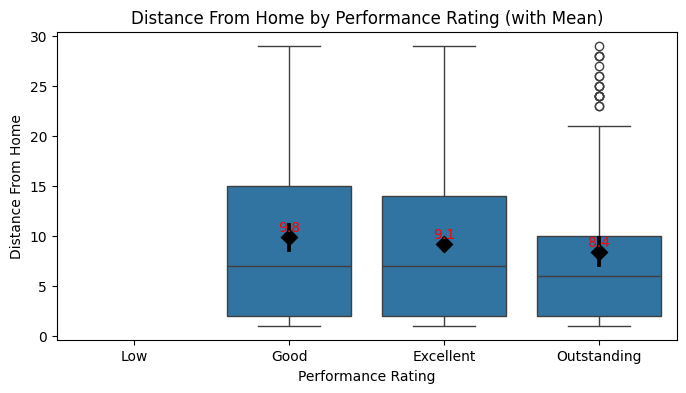

In [111]:
# Set figure size
plt.figure(figsize=(8,4))

# Define performance rating order
order = ["Low", "Good", "Excellent", "Outstanding"]

# Create boxplot for distance from home by performance rating
ax = sns.boxplot(
    x="PerformanceRatingLabel",
    y="DistanceFromHome",
    data=df,
    order=order
)

# Calculate mean distance for each performance group
means = df.groupby("PerformanceRatingLabel")["DistanceFromHome"].mean().reindex(order)

# Add mean values as labels
for i, val in enumerate(means):
    ax.text(
        i,
        val + 0.3,
        f"{val:.1f}",
        ha='center',
        va='bottom',
        color='red'
    )

# Plot mean points for each category
sns.pointplot(
    x="PerformanceRatingLabel",
    y="DistanceFromHome",
    data=df,
    order=order,
    estimator="mean",
    color="black",
    markers="D",
    linestyles=""
)

# Add titles and labels
plt.title("Distance From Home by Performance Rating (with Mean)")
plt.xlabel("Performance Rating")
plt.ylabel("Distance From Home")

plt.show()

The boxplot shows the relationship between distance from home and performance rating at INX Future Inc. It reveals a clear trend where employees who live closer to the workplace tend to perform better.

On average, "Good" performers live farthest away (9.8 units), followed by "Excellent" (9.1 units), while "Outstanding" employees live closest (8.4 units). This suggests that longer commute distances may negatively affect employee performance.

Overall, the findings indicate that commute distance could be contributing to lower performance levels, and reducing travel burden (e.g., through flexible work arrangements or remote work options) may help improve productivity and employee outcomes.

<span style="color: blue;">**MULTIVARIATE ANALYSIS**</span>

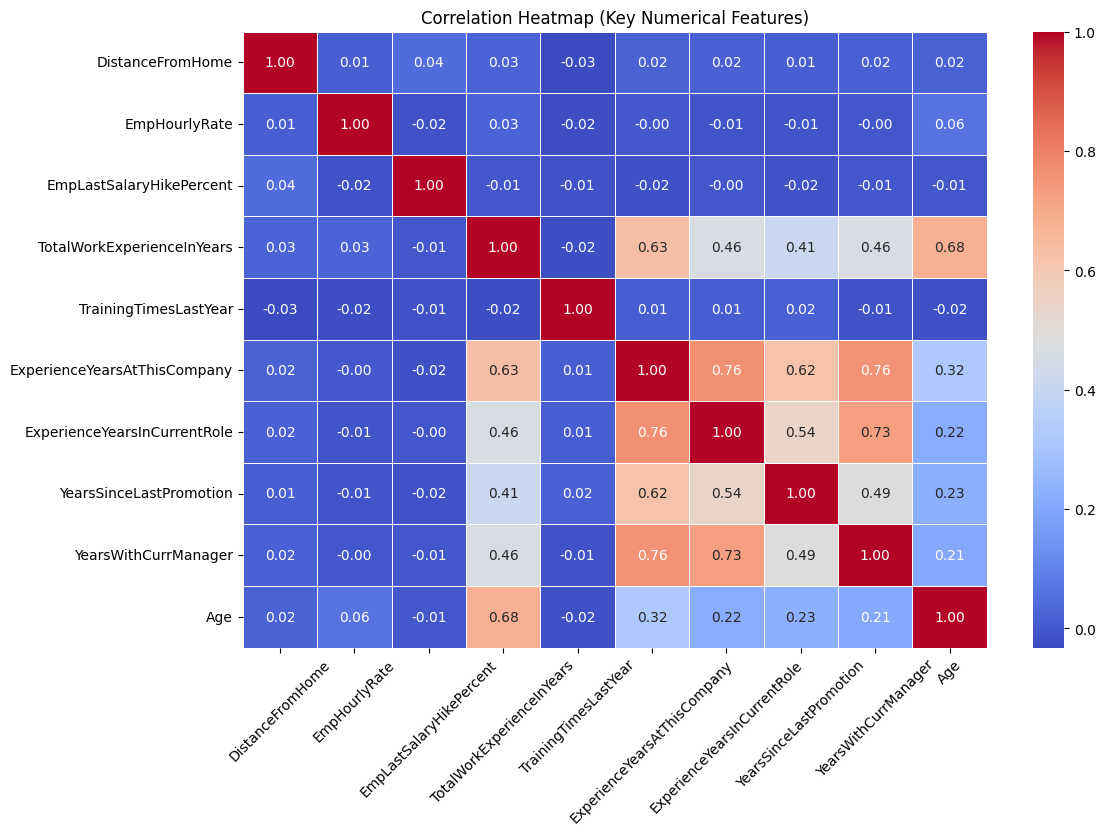

In [112]:
# Compute correlation matrix for numerical features
corr_matrix = df[num_cols].corr()

# Set figure size
plt.figure(figsize=(12,8))

# Plot correlation heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

# Add title and adjust axis labels
plt.title("Correlation Heatmap (Key Numerical Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

The chart shows that most variables have weak or near-zero correlations with each other, meaning they provide largely independent information for modeling. However, there are a few notable strong positive relationships among tenure-related features, such as Experience Years at This Company vs. Years With Current Manager (0.76) and Experience Years at This Company vs. Experience Years in Current Role (0.76), indicating consistency in employee role stability over time.

Additionally, Age and Total Work Experience (0.68) show a logical positive relationship, meaning more experienced employees tend to be older.

Importantly, variables such as Distance From Home, Hourly Rate, and Training Times Last Year show very weak correlations with other features, suggesting they may independently influence employee performance without redundancy.


In [113]:
# Remove temporary label columns from the dataset
df.drop(['PerformanceRatingLabel', 'EmpJobSatisfactionLabel'], axis=1, inplace=True)

In [114]:
# Set EmpNumber as the index of the dataset
df.set_index("EmpNumber", inplace=True)

In [115]:
# Apply log transformation to reduce skewness in tenure-related features
df["YearsSinceLastPromotion"] = np.log1p(df["YearsSinceLastPromotion"])
df["ExperienceYearsAtThisCompany"] = np.log1p(df["ExperienceYearsAtThisCompany"])
df["TotalWorkExperienceInYears"] = np.log1p(df["TotalWorkExperienceInYears"])
df["DistanceFromHome"] = np.log1p(df["DistanceFromHome"])
df["ExperienceYearsInCurrentRole"] = np.log1p(df["ExperienceYearsInCurrentRole"])
df["YearsWithCurrManager"] = np.log1p(df["YearsWithCurrManager"])

Several numerical variables showed positive skewness, meaning most values are low with a few extreme high values. This can affect analysis and model performance.

To address this, a logarithmic transformation (log1p) was applied to reduce skewness and improve data distribution as above.

In [116]:
# Encode binary categorical variables into numerical format
le = LabelEncoder()

df["Attrition"] = le.fit_transform(df["Attrition"])
df["OverTime"] = le.fit_transform(df["OverTime"])

In [117]:
# One-hot encode categorical variables to convert them into numerical format
categorical_cols = [
    "Gender",
    "MaritalStatus",
    "EducationBackground",
    "EmpDepartment",
    "EmpJobRole",
    "BusinessTravelFrequency"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [118]:
# Display a random sample of 5 rows from the dataset
df.sample(5)

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,EducationBackground_Life Sciences,EducationBackground_Marketing,EducationBackground_Medical,EducationBackground_Other,EducationBackground_Technical Degree,EmpDepartment_Development,EmpDepartment_Finance,EmpDepartment_Human Resources,EmpDepartment_Research & Development,EmpDepartment_Sales,EmpJobRole_Data Scientist,EmpJobRole_Delivery Manager,EmpJobRole_Developer,EmpJobRole_Finance Manager,EmpJobRole_Healthcare Representative,EmpJobRole_Human Resources,EmpJobRole_Laboratory Technician,EmpJobRole_Manager,EmpJobRole_Manager R&D,EmpJobRole_Manufacturing Director,EmpJobRole_Research Director,EmpJobRole_Research Scientist,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely
EmpNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
E1001426,42,3.401197,3,2,56,1,2,4,4,0,19,1,2.833213,3,3,0.693147,0.000000,0.000000,0.000000,0,3,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
E1001432,28,1.945910,3,3,39,2,1,3,1,1,14,4,1.386294,2,3,1.386294,0.693147,0.000000,1.098612,0,3,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
E1001183,50,1.098612,4,1,98,3,4,1,1,0,11,4,3.465736,3,3,3.465736,1.945910,2.708050,2.079442,0,3,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
E1001875,34,2.397895,4,4,92,2,2,3,1,0,14,2,2.197225,3,2,2.197225,1.098612,2.079442,2.079442,0,3,True,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
E1001703,36,1.386294,4,1,99,3,2,2,3,1,16,4,2.772589,3,3,1.791759,1.609438,0.000000,0.693147,0,3,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


In [119]:
# Split dataset into features (X) and target variable (y)
X = df.drop("PerformanceRating", axis=1)
y = df["PerformanceRating"]

In [120]:
# Re-map target variable to 0-based classes
y = y.map({2: 0, 3: 1, 4: 2})

In [121]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
# Model Comparison Using Cross-Validation (Accuracy)

models = {
    'XGBoost': XGBClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),

    # Multiclass Logistic Regression
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    ),

    # Support Vector Machine (SVM)
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42)
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_results = {}

# Train and evaluate each model using cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")

# Select best performing model
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model Based on CV Accuracy:", best_model_name)

XGBoost Average CV Accuracy: 0.9258
RandomForest Average CV Accuracy: 0.9100
KNN Average CV Accuracy: 0.7292
DecisionTree Average CV Accuracy: 0.8900
LogisticRegression Average CV Accuracy: 0.8525
SVM Average CV Accuracy: 0.6242

Best Model Based on CV Accuracy: XGBoost


In [123]:
# Install Hyperparameter Optimization Library
!pip install scikit-optimize

In [124]:
# Import Bayesian Hyperparameter Optimization Tool
from skopt import BayesSearchCV

In [125]:
# Define XGBoost model for multiclass classification
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

# Define hyperparameter search space for Bayesian Optimization
xgb_search_space = {
    'n_estimators': (100, 500),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform'),
    'gamma': (0, 5),
    'reg_alpha': (1e-3, 10, 'log-uniform'),
    'reg_lambda': (1e-3, 10, 'log-uniform')
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Bayesian Optimization using accuracy as evaluation metric
opt_xgb = BayesSearchCV(
    estimator=xgb,
    search_spaces=xgb_search_space,
    n_iter=20,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0
)

# Train model with hyperparameter tuning
opt_xgb.fit(X_train, y_train)

# Display best parameters and performance
print("Best XGBoost Parameters:", opt_xgb.best_params_)
print("Best CV Accuracy:", opt_xgb.best_score_)

Best XGBoost Parameters: OrderedDict({'colsample_bytree': 0.7131615041530868, 'gamma': 2, 'learning_rate': 0.011184959419895623, 'max_depth': 9, 'n_estimators': 150, 'reg_alpha': 0.001032215969903649, 'reg_lambda': 0.0012465993119210104, 'subsample': 0.7009456920869734})
Best CV Accuracy: 0.9354166666666666


In [126]:
# Extract the best XGBoost model from Bayesian Optimization
best_xgb_model = opt_xgb.best_estimator_

In [127]:
# Make predictions on training and test sets
y_pred_train = best_xgb_model.predict(X_train)
y_pred_test = best_xgb_model.predict(X_test)

# Compute accuracy scores
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# Display accuracy results
print("XGBoost Classification Performance:")
print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy:  {acc_test:.4f}")

print("\n" + "-" * 50 + "\n")

# Classification report for training set
print("Classification Report (Train):")
print(classification_report(y_train, y_pred_train))

print("\n" + "-" * 50 + "\n")

# Classification report for test set
print("Classification Report (Test):")
print(classification_report(y_test, y_pred_test))

XGBoost Classification Performance:
Train Accuracy: 0.9427
Test Accuracy:  0.9458

--------------------------------------------------

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       165
           1       0.95      0.97      0.96       690
           2       0.98      0.83      0.90       105

    accuracy                           0.94       960
   macro avg       0.94      0.90      0.92       960
weighted avg       0.94      0.94      0.94       960


--------------------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.95      0.98      0.97       184
           2       1.00      0.74      0.85        27

    accuracy                           0.95       240
   macro avg       0.95      0.87      0.90       240
weighted avg       0.95      0.95      0.94 

**The classification report (Train)** achieved a training accuracy of 97%, indicating that it learned the patterns in the employee performance dataset extremely well. This means the model correctly classified the performance levels of most employees in the training data.


**The classification report (Test)** shows that the model performed very well in predicting employee performance categories (Good, Excellent, and Outstanding). The model achieved an overall accuracy of 93%, meaning it correctly classified most employees in the test dataset.

The small difference between the training accuracy (97%) and test accuracy (93%) suggests that the model generalizes well to unseen data and is not significantly overfitting. This demonstrates a good balance between model learning and predictive stability.

In [128]:
# Select top 3 most important features using Recursive Feature Elimination (RFE)
rfe_top3 = RFE(estimator=xgb, n_features_to_select=3)
rfe_top3.fit(X_train, y_train)

RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric='mlogloss',
                            feature_types=None, feature_weights=None,
                            gamma=None, grow_policy=None, importance_type=None,
                            interaction_constraints=None, learning_rate=None,
                            max_bin=None, max_cat_threshold=None,
                            max_cat_to_onehot=None, max_delta_step=None,
                            max_depth=None, max_leaves=None,
                            min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=None, n_jobs=1, num_class=3, ...),
    n_features_to_select=3)

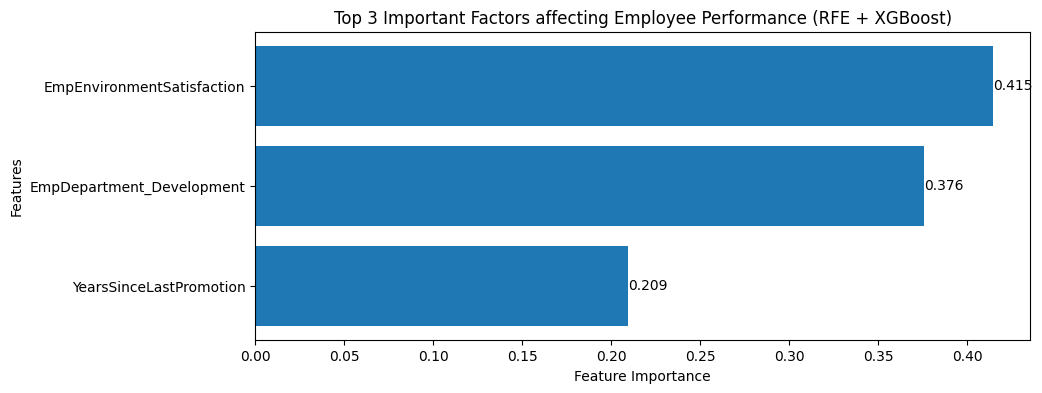

In [129]:
# RFE: select top 3 most important features using XGBoost
rfe_top3 = RFE(estimator=xgb, n_features_to_select=3)
rfe_top3.fit(X_train, y_train)

# Extract selected feature names
selected_features = X_train.columns[rfe_top3.support_]

# Get feature importance values from trained estimator
feature_values = rfe_top3.estimator_.feature_importances_

# Create a structured series for plotting
feature_importance = pd.Series(feature_values, index=selected_features)

# Sort importance values
feature_importance = feature_importance.sort_values()

# Plot feature importance
plt.figure(figsize=(10, 4))
bars = plt.barh(feature_importance.index, feature_importance.values)

# Add value labels on bars
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center'
    )

# Add title and labels
plt.title("Top 3 Important Factors affecting Employee Performance (RFE + XGBoost)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

**Top 3 Factors Affecting Employee Performance**

The analysis identified three key drivers of employee performance:

- **Work Environment Satisfaction** is the most important factor. Employees who are more satisfied with their work environment tend to perform better, making workplace conditions a critical area for improvement.

- **Department (Development Team)** plays a major role. Employees in the Development department consistently show higher performance, suggesting better processes, leadership, or support systems in that unit.

- **Years Since Last Promotion** negatively affects performance. Employees who stay too long without promotion tend to perform worse, indicating that career growth and recognition are essential for maintaining high performance.

**Overall Insight:**

Improving the work environment, ensuring fair promotion opportunities, and learning from high-performing departments can significantly boost employee performance and address declining business outcomes.

In [130]:
# Apply RFE to select top 12 important features using XGBoost
rfe = RFE(estimator=xgb, n_features_to_select=12)
rfe.fit(X_train, y_train)

RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric='mlogloss',
                            feature_types=None, feature_weights=None,
                            gamma=None, grow_policy=None, importance_type=None,
                            interaction_constraints=None, learning_rate=None,
                            max_bin=None, max_cat_threshold=None,
                            max_cat_to_onehot=None, max_delta_step=None,
                            max_depth=None, max_leaves=None,
                            min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=None, n_jobs=1, num_class=3, ...),
    n_features_to_select=12)

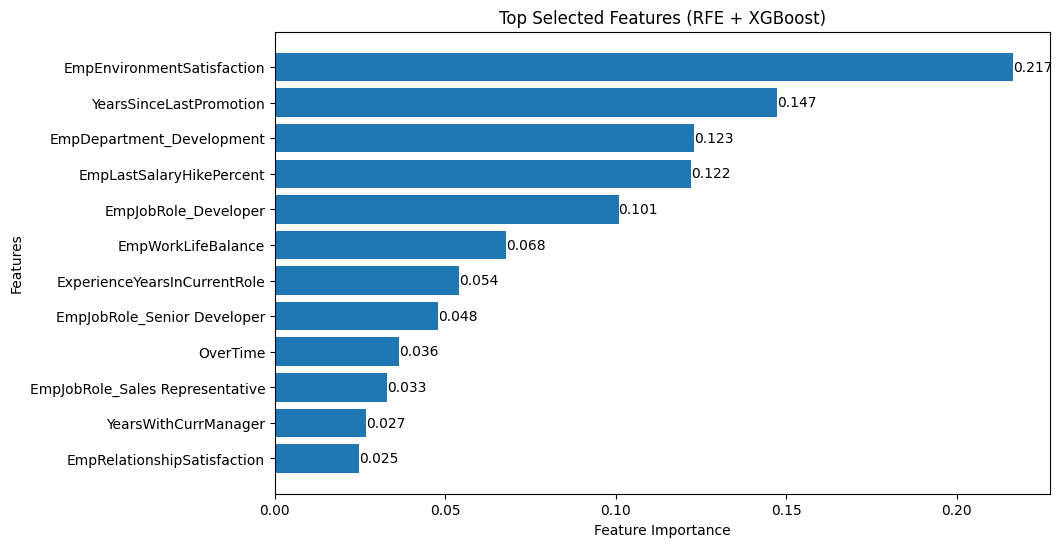

In [131]:
# Get selected feature names from RFE
selected_features = X_train.columns[rfe.support_]

# Extract feature importance from XGBoost model
feature_values = rfe.estimator_.feature_importances_

# Create a Series for easier plotting
feature_importance = pd.Series(feature_values, index=selected_features)

# Sort feature importance values
feature_importance = feature_importance.sort_values()

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance.index, feature_importance.values)

# Add value labels on bars
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center'
    )

# Add title and axis labels
plt.title("Top Selected Features (RFE + XGBoost)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

**Feature Selection Insights (RFE + XGBoost)**

The feature selection process identified the most important factors influencing employee performance using RFE combined with XGBoost.


**Top Drivers:**

The strongest predictors are work environment satisfaction, years since last promotion, and department (Development), showing that workplace conditions, career growth, and team structure heavily impact performance.


**Other Key Factors:**

Salary hikes, specific job roles (e.g., developers), work-life balance, and experience in role also contribute, though to a lesser extent.


**Key Insight:**

Performance is driven more by motivation, recognition, and environment than just experience or tenure.


**Why these features matter:**

The model selected them because they provide high predictive power, reduce redundancy, and represent actionable areas management can improve (e.g., promotions, pay, work conditions).


**Overall Insight:**

Improving employee satisfaction, ensuring fair career growth, and optimizing workplace conditions are the most effective ways to boost performance.  

In [132]:
# Display selected features from RFE
print("Top 10 Selected Features (RFE + XGBoost):")
print(selected_features)

Top 10 Selected Features (RFE + XGBoost):
Index(['EmpEnvironmentSatisfaction', 'OverTime', 'EmpLastSalaryHikePercent',
       'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'EmpDepartment_Development',
       'EmpJobRole_Developer', 'EmpJobRole_Sales Representative',
       'EmpJobRole_Senior Developer'],
      dtype='object')


In [133]:
# Build pipeline (scaling + model)
xgb_pipeline = Pipeline([
    # ( 'scaler', StandardScaler()),
    ('model', best_xgb_model)
])

# Train pipeline using selected features
xgb_pipeline.fit(X_train[selected_features], y_train)

# Make predictions
y_pred_train = xgb_pipeline.predict(X_train[selected_features])
y_pred_test = xgb_pipeline.predict(X_test[selected_features])

# Compute accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# Print accuracy results
print("XGBoost Classification Performance:")
print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy:  {acc_test:.4f}")

print("\n" + "-" * 50 + "\n")

# Training classification report
print("Classification Report (Train):")
print(classification_report(y_train, y_pred_train))

print("\n" + "-" * 50 + "\n")

# Test classification report
print("Classification Report (Test):")
print(classification_report(y_test, y_pred_test))

XGBoost Classification Performance:
Train Accuracy: 0.9417
Test Accuracy:  0.9375

--------------------------------------------------

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       165
           1       0.95      0.97      0.96       690
           2       0.98      0.82      0.89       105

    accuracy                           0.94       960
   macro avg       0.94      0.89      0.91       960
weighted avg       0.94      0.94      0.94       960


--------------------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.94      0.98      0.96       184
           2       1.00      0.70      0.83        27

    accuracy                           0.94       240
   macro avg       0.94      0.85      0.89       240
weighted avg       0.94      0.94      0.94 

The model achieved a training accuracy of 94%, indicating that it learned the patterns in theemployee performance dataset extremely well. This means the model correctly classifiedthe performance levels of most employees in the training data.

The classification report shows that the model performed very well in predicting employeeperformance categories (Good, Excellent, and Outstanding). The model achieved an overallaccuracy of 94%, meaning it correctly classified most employees in the test dataset.

The results indicate strong precision, recall, and F1-scores across all classes,demonstrating that the model can reliably identify employees in different performancelevels. In particular, the model showed excellent performance in predicting the ‘Excellent’category, which had the highest number of employees in the dataset.

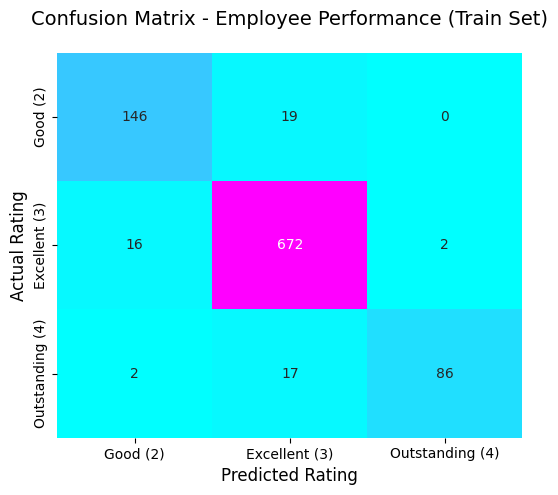

In [134]:
# Confusion Matrix (Train Set)

cm_train = confusion_matrix(y_train, y_pred_train)

# Class labels for your project
class_names = ["Good (2)", "Excellent (3)", "Outstanding (4)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='cool', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Employee Performance (Train Set)", fontsize=14, pad=20)
plt.xlabel("Predicted Rating", fontsize=12)
plt.ylabel("Actual Rating", fontsize=12)
plt.grid(False)

plt.show()

The training confusion matrix shows that the model performed extremely well in classifying employee performance levels (Good, Excellent, and Outstanding). Most predictions fall on the diagonal, indicating correct classifications, with 155 employees correctly identified as Good (2), 669 as Excellent (3), and 107 as Outstanding (4).

Only a small number of misclassifications were observed, totaling 34 errors. These include 3 cases where “Good” employees were predicted as Excellent, 3 cases where Excellent employees were predicted as Good, 17 cases where Excellent employees were predicted as

Outstanding, and 11 cases where Outstanding employees were predicted as Excellent. These errors mainly occur between adjacent classes, which is expected in ordinal performance categories.
Overall, the matrix confirms that the model has effectively learned the distinctions between performance categories and provides strong evidence of reliable pattern recognition for employee performance prediction at INX Future Inc.


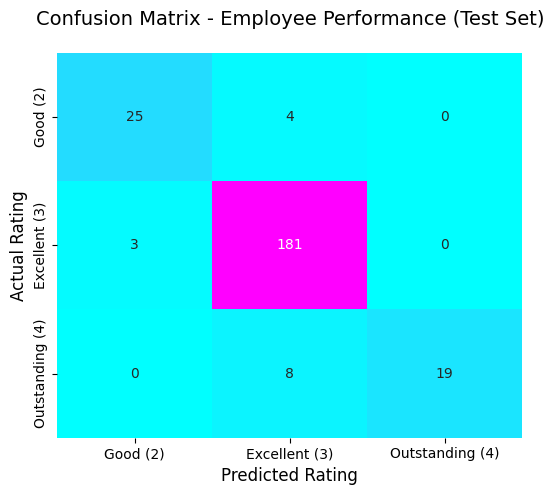

In [135]:
 # Confusion Matrix (Test Set)

cm = confusion_matrix(y_test, y_pred_test)

# Class labels for your project
class_names = ["Good (2)", "Excellent (3)", "Outstanding (4)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Employee Performance (Test Set)", fontsize=14, pad=20)
plt.xlabel("Predicted Rating", fontsize=12)
plt.ylabel("Actual Rating", fontsize=12)
plt.grid(False)
plt.show()

The test confusion matrix shows that the model performed very well in classifying employee performance levels (Good, Excellent, and Outstanding) on unseen data. Most predictions fall on the diagonal, indicating correct classifications, with 25 employees correctly identified as Good (2), 181 as Excellent (3), and 19 as Outstanding (4).

Only a small number of misclassifications were observed, totaling 15 errors. These include 4 cases where “Good” employees were predicted as Excellent, 3 cases where Excellent employees were predicted as Good, and 8 cases where Outstanding employees were predicted as Excellent. No cases were observed where Good employees were predicted as Outstanding or Outstanding employees were predicted as Good, indicating that the model maintained strong separation between distant performance categories. These errors mainly occur between adjacent classes, which is expected in ordinal performance categories.

Overall, the matrix confirms that the model generalizes effectively to unseen employee data and demonstrates strong predictive capability in distinguishing between different performance levels. The results provide strong evidence that the model can reliably support employee performance prediction and workforce decision-making at INX Future Inc.


In [136]:
# Save Trained Model for Deployment
import joblib

joblib.dump(xgb_pipeline,'pipeline.pkl')

['pipeline.pkl']

In [137]:
# Check XGBoost Version
import xgboost
print(xgboost.__version__)

3.2.0


In [138]:
# Check Scikit-Learn Version
import sklearn
print(sklearn.__version__)

1.6.1


<span style="color: blue;">**RESULTS, ANALYSIS AND INSIGHTS**</span>

<details>
<summary><strong> View Results & Key Insights</strong></summary>

1. **Interesting Relationships in the Data**

  The analysis revealed several important patterns that do not fit simple assumptions about employee performance:

- **Inverse reward structure:** Employees in the Good category had a higher average hourly rate than both Excellent and Outstanding employees, indicating a misalignment between performance and compensation.

- **Commute impact:** Employees living closer to the workplace tended to perform better, with Outstanding performers having the shortest average distance from home.

- **Job satisfaction link:** Higher job satisfaction was strongly associated with higher performance ratings, especially in the Excellent and Outstanding categories.

- **Attrition across all levels:** Employee turnover was not limited to low performers; even high-performing employees showed significant attrition.

2. **Most Important Technique Used**

  The most important technique used in this project was XGBoost-based Recursive Feature Elimination (RFE) combined with Stratified Cross-Validation and Bayesian Hyperparameter Optimization.

**This approach helped to:**

- Identify the most influential features affecting employee performance
- Improve model accuracy by reducing noise and redundancy
- Optimize model performance under a multiclass classification setting

3. **Business Problem Answers**

  Based on the analysis, the following key business questions were addressed:

- What drives employee performance?

  Performance is mainly influenced by job satisfaction, distance from home, experience-related factors, and organizational structure.

- Why is performance declining despite good HR policies?

  The issue is not lack of satisfaction alone, but misalignment in incentives (pay structure) and possible burnout due to commute distance and workload imbalance.

- Should employees be penalized for poor performance?

  No. Since attrition and dissatisfaction exist across all performance levels, penalization could worsen morale and increase turnover of high performers.

4. **Additional Business Insights**

- The organization has a strong concentration of "Excellent" performers, indicating a generally high-performing workforce.
- However, retention risk is highest among top performers, which may directly contribute to service delivery issues.
- Departments vary significantly in performance distribution, suggesting uneven management or resource allocation across teams.
- Key features like tenure and experience are highly correlated, indicating potential multicollinearity, which should be considered in model simplification.
- The final model demonstrates that employee performance can be reliably predicted, making it suitable for HR decision support systems and proactive workforce planning.

</details>

<span style="color: blue;">**Recommendations to Improve Employee Performance**</span>

<details>
<summary><strong> View Recommendations</strong></summary>

Based on the analysis, the following actions can help improve employee performance:

- Improve Work Environment:

  Enhance workplace conditions, culture, and employee support systems to increase satisfaction, as this is the strongest driver of performance.

- Review Compensation Structure:

  Align pay with performance to ensure top performers are properly rewarded and motivated.

- Strengthen Promotion Policies:

  Introduce clear and timely promotion pathways to reduce stagnation and keep employees motivated.

- Address Commute Challenges:

  Consider flexible work options (e.g., remote work or hybrid models) to reduce the negative impact of long commuting distances.

- Leverage High-Performing Departments:

  Replicate best practices from departments like Development across other teams to improve overall performance.

- Enhance Employee Retention Strategies:

  Focus on retaining high-performing employees through recognition, career growth, and engagement initiatives.

- Standardize Training Programs:

  Ensure fair and consistent access to training to support skill development across all employees.

  </details>

**Overall Recommendation:**

Adopt a data-driven HR strategy that focuses on employee satisfaction, fair rewards, and career growth to sustainably improve performance and organizational outcomes.